<a href="https://colab.research.google.com/github/Mikko18/Python-exercises-nov-dec-25/blob/main/reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

Voit ladata tiedostoja Colabin tiedostojärjestelmään käyttämällä seuraavaa koodia. Tiedostot ladataan nykyiseen työhakemistoon, ja ne ovat käytettävissä koodissasi. Huomaa, että ladatut tiedostot poistetaan Colab-istunnon päättyessä, joten sinun on ladattava ne uudelleen, jos käynnistät istunnon uudelleen.

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

In [ ]:
import pandas as pd

url = 'threads_reviews.csv'
Dataset = pd.read_csv(url)

In [ ]:
Dataset.head(10)

,source,review_description,rating,review_date
0,Google Play,Meh. Not the greatest experience on a Chromebo...,2,2023-07-08 14:18:24
1,Google Play,Pretty good for a first launch!! Its easy to u...,3,2023-07-19 20:52:48
2,Google Play,"For a brand new app, it's very well optimized....",3,2023-07-06 23:03:11
3,Google Play,"Great app with a lot of potential! However, th...",3,2023-07-10 00:53:25
4,Google Play,"The app is good, but it needs a lot of functio...",3,2023-07-06 16:57:43
5,Google Play,"Currently, it's very challenging to use. It's ...",2,2023-07-18 22:30:10
6,Google Play,I still don’t want to see content from people ...,1,2023-07-19 19:35:31
7,Google Play,Could be great if all pages loaded when you cl...,2,2023-07-06 14:35:15
8,Google Play,I'm liking the concept! There is room for impr...,3,2023-07-09 03:27:39
9,Google Play,Not bad! This is its first launch. There is st...,5,2023-07-06 23:41:13


In [ ]:
# Nominal attributes and binary attributes
df = pd.DataFrame({
    'source': ['Google Play', 'App Store', 'Google Play'],
    'review_description': ['Pretty good for a first launch!!', 'Great app with a lot of potential!', 'Meh. Not the greatest experience on a Chromebook...'],
    'rating': [3, 1, 2],
    'review_date': ['2023-07-19 20:52:48', '2023-07-10 00:53:25', '2023-07-08 14:18:24']
})

# Identification
nominal_cols = df.select_dtypes(include=['object', 'category']).columns
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

# Print
print("Nominal attributes:", list(nominal_cols))
print("Binary attributes:", binary_cols)

Nominal attributes: ['source', 'review_description', 'review_date']
Binary attributes: ['source']


In [ ]:
# Ordinal attributes
df = pd.DataFrame({
    'source': ['Google Play', 'App Store', 'Google Play'],
    'review_description': ['Pretty good for a first launch!!', 'Great app with a lot of potential!', 'Meh. Not the greatest experience on a Chromebook...'],
    'rating': [3, 1, 2],
    'review_date': ['2023-07-19 20:52:48', '2023-07-10 00:53:25', '2023-07-08 14:18:24']
})

# Define ordinal mappings for relevant columns
ordinal_mappings = {
    'rating': [1, 2, 3, 4, 5],
    'review_date': ['2023-07-19 20:52:48', '2023-07-10 00:53:25', '2023-07-08 14:18:24']
}

# Convert to ordered categorical dtype
for col, order in ordinal_mappings.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)

# Identify and print
ordinal_cols = [col for col in df.columns if str(df[col].dtype) == 'category' and df[col].cat.ordered]
print("Ordinal attributes:", ordinal_cols)

Ordinal attributes: ['rating', 'review_date']


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("threads_reviews.csv")

col = df["rating"].to_numpy()

mean_val = np.mean(col)

print("Keskiarvo:", mean_val)

Keskiarvo: 3.398480704952902


In [ ]:
col = df["rating"].to_numpy()

print("Variance:", np.var(col))
print("Keskihajonta:", np.std(col))

Variance: 3.0675880897978622
Keskihajonta: 1.7514531366262307


In [ ]:
col = df["rating"].to_numpy()

print("Min:", np.min(col))
print("Max:", np.max(col))

Min: 1
Max: 5


In [ ]:
col = df["rating"].to_numpy()

print("Sum:", np.sum(col))

Sum: 111844


In [ ]:
# Check missing values
df.isnull().sum()

# Fix missing values
df['review_description'] = df['review_description'].fillna("No review")
df = df.dropna(subset=['rating', 'source', 'review_date'])

NameError: name 'df' is not defined

In [ ]:
df.duplicated().sum()   # count duplicates
df = df.drop_duplicates()

Saving threads_reviews.csv to threads_reviews (3).csv


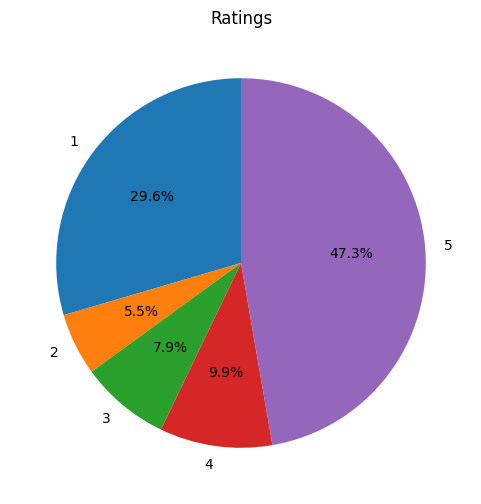

In [ ]:
#Pie Chart
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
url = "threads_reviews.csv"
threads_reviews = pd.read_csv(url)


uploaded = files.upload()
rating_counts = threads_reviews["rating"].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct="%1.1f%%",startangle=90)
plt.title("Ratings")
plt.show()

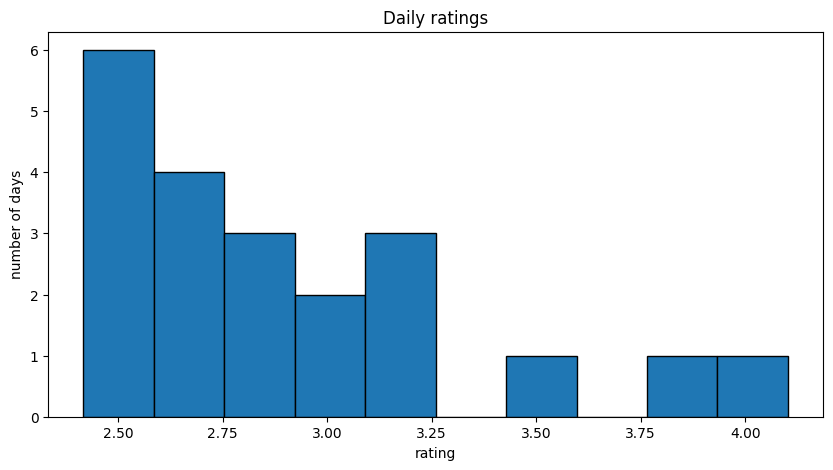

In [ ]:
#histogram
threads_reviews["review_date"] = pd.to_datetime(threads_reviews["review_date"])

daily = threads_reviews.groupby(threads_reviews["review_date"].dt.date)["rating"].mean()

plt.figure(figsize=(10, 5))

plt.hist(daily.values, bins=10, edgecolor="black")

plt.title("Daily ratings")
plt.xlabel("rating")
plt.ylabel("number of days")

plt.show()

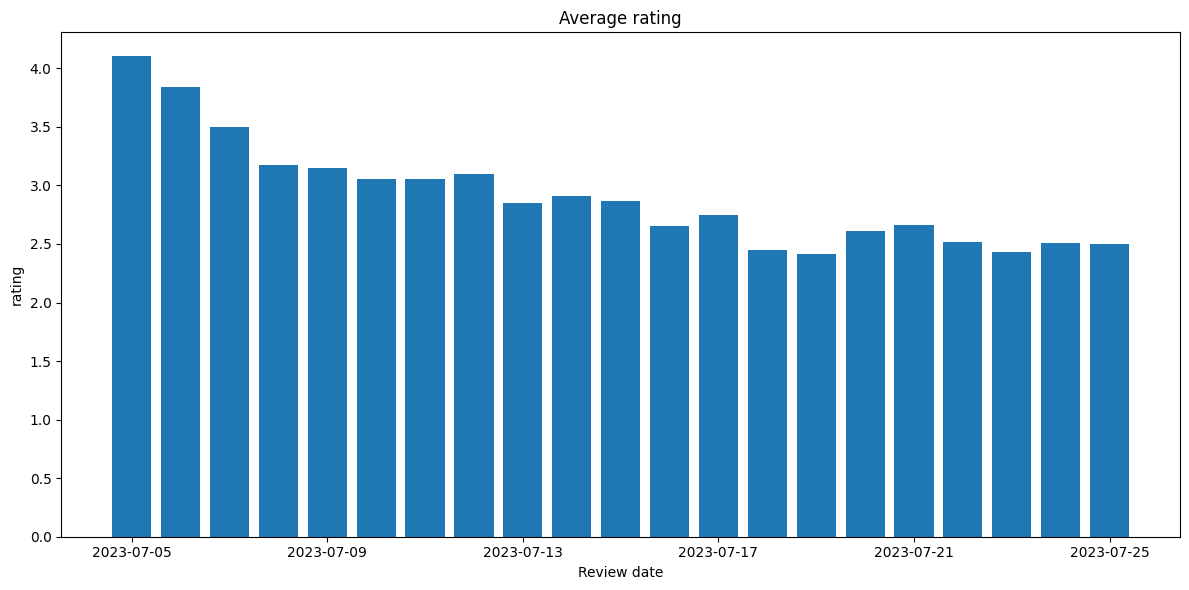

In [ ]:
#Bar plot

threads_reviews["review_date"] = pd.to_datetime(threads_reviews["review_date"])

daily = threads_reviews.groupby(threads_reviews["review_date"].dt.date)["rating"].mean()

plt.figure(figsize=(12, 6))
plt.bar(daily.index, daily.values)

plt.title("Average rating")
plt.xlabel("Review date")
plt.ylabel("rating")


plt.tight_layout()
plt.show()

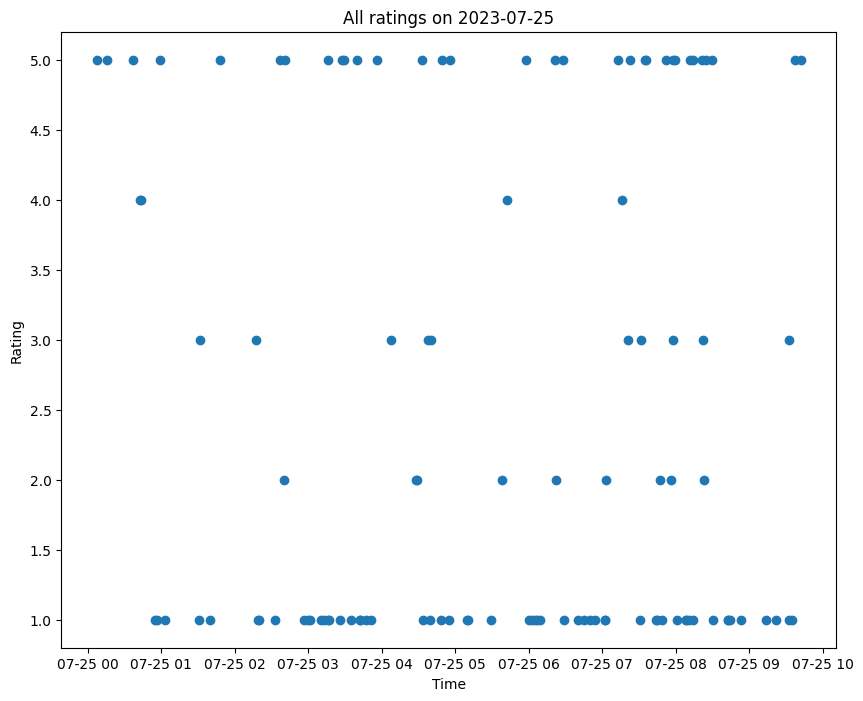

In [ ]:
#Scatter plot
threads_reviews["review_date"] = pd.to_datetime(threads_reviews["review_date"])
plt.figure(figsize=(10, 8))

paiva = "2023-07-25"


paivan_arvostelut = threads_reviews[
    threads_reviews["review_date"].dt.date == pd.to_datetime(paiva).date()
]


plt.scatter(paivan_arvostelut["review_date"], paivan_arvostelut["rating"])

plt.title("All ratings on 2023-07-25")
plt.xlabel("Time")
plt.ylabel("Rating")


plt.show()

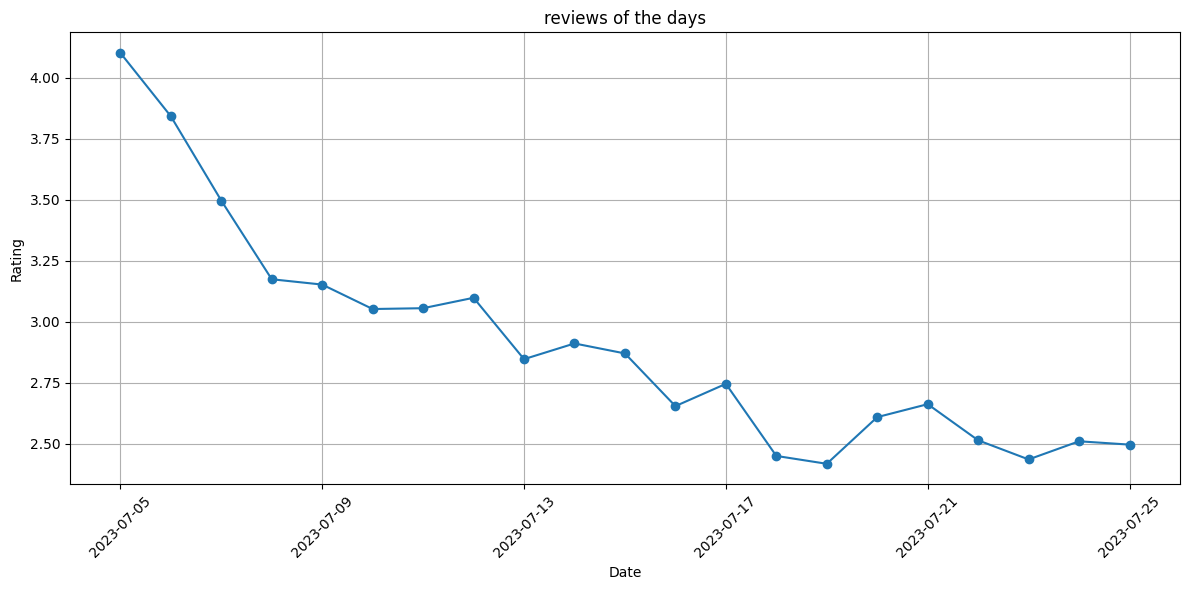

In [ ]:
#Line plot
threads_reviews["review_date"] = pd.to_datetime(threads_reviews["review_date"])
date_threads = threads_reviews.groupby(threads_reviews["review_date"].dt.date)["rating"].mean()

plt.figure(figsize=(12, 6))
plt.plot(date_threads.index, date_threads.values, marker='o')
plt.title("reviews of the days")
plt.xlabel("Date")
plt.ylabel("Rating")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

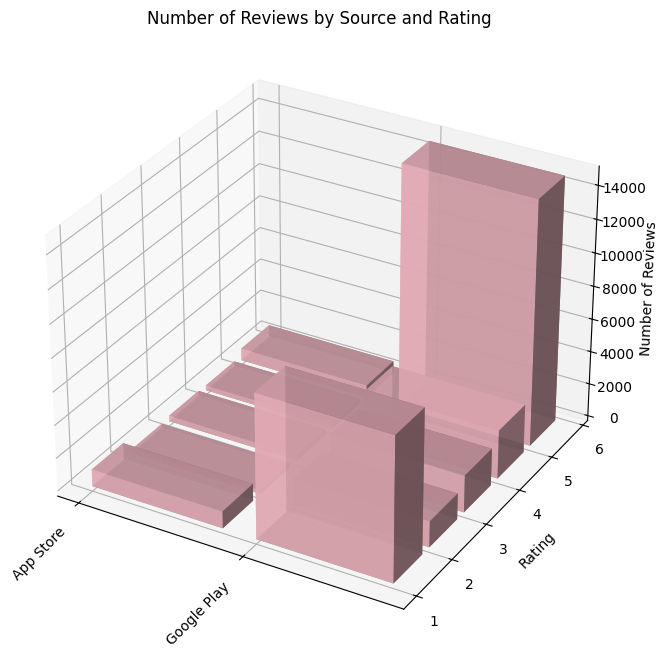

In [ ]:
#3D Plot

from mpl_toolkits.mplot3d import Axes3D

grouped = threads_reviews.groupby(['source', 'rating']).size().reset_index(name='count')

grouped['source_number'] = grouped['source'].astype('category').cat.codes

x = grouped['source_number'].values
y = grouped['rating'].values
z = np.zeros(len(grouped))

dx = np.ones(len(grouped)) * 0.8
dy = np.ones(len(grouped)) * 0.8
dz = grouped['count'].values

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

ax.bar3d(x, y, z, dx, dy, dz, color='pink', alpha=0.8)

sources = grouped['source'].astype('category').cat.categories
ax.set_xticks(range(len(sources)))
ax.set_xticklabels(sources, rotation=45, ha='right')


ax.set_ylabel('Rating')
ax.set_zlabel('Number of Reviews')
plt.title("Number of Reviews by Source and Rating")
plt.show()


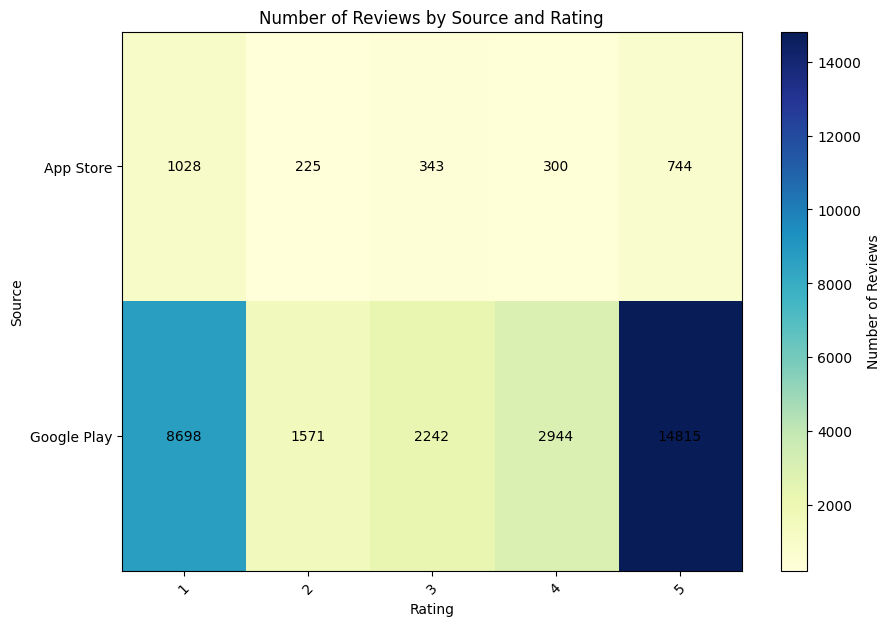

In [ ]:

threads_table = threads_reviews.pivot_table(
    index='source',
    columns='rating',
    values='review_description',
    aggfunc='count',
    fill_value=0
)

Data = threads_table.values

fig, ax = plt.subplots(figsize=(10,7))
cax = ax.imshow(Data, cmap='YlGnBu', aspect='auto')

ax.set_xticks(np.arange(len(threads_table.columns)))
ax.set_yticks(np.arange(len(threads_table.index)))

ax.set_xticklabels(threads_table.columns)
ax.set_yticklabels(threads_table.index)

plt.xticks(rotation=45)

for i in range(len(threads_table.index)):
    for j in range(len(threads_table.columns)):
        ax.text(j, i, Data[i, j], ha='center', va='center', color='black')

plt.xlabel('Rating')
plt.ylabel('Source')
plt.title('Number of Reviews by Source and Rating')

fig.colorbar(cax, label='Number of Reviews')

plt.show()